# 03 - Model Comparison

Builds the assignment's required outputs entirely from what `02_experiments.
ipynb` already wrote to `results/` - the `ExperimentTracker` log and the
saved per-model/per-square predictions - so nothing here recomputes a
prediction or a metric; this notebook is presentation and interpretation of
evidence that already exists on disk.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "forecasting").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json

import matplotlib.pyplot as plt
import pandas as pd

from forecasting.tracking import ExperimentTracker
from forecasting.viz import apply_style, CATEGORICAL, INK_SECONDARY
from forecasting.utils import hardware_info

apply_style()
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "figures"

with open(RESULTS_DIR / "top_squares.json") as f:
    TOP3 = json.load(f)["top3_square_ids"]

MODEL_NAMES = ["SARIMA", "GBM", "LSTM"]

log = ExperimentTracker(RESULTS_DIR / "experiment_log.csv").read_log()
final_log = log[log["phase"] == "final"].copy()
final_log

,timestamp,model,square_id,phase,params,mae,mape,rmse,train_seconds,predict_seconds,rationale
16,2026-09-18 13:25:27+00:00,SARIMA,5161,final,"{""order"": [2, 1, 2], ""n_harmonics"": 3}",82.567241,8.536348,124.255727,5.792278,117.965907,Final Dec16-22 evaluation on square 5161
17,2026-09-18 13:25:40+00:00,GBM,5161,final,"{""n_estimators"": 100, ""max_depth"": 3, ""learnin...",80.668467,8.639132,117.483657,3.690174,8.974237,Final Dec16-22 evaluation on square 5161
18,2026-09-18 13:26:21+00:00,LSTM,5161,final,"{""hidden_size"": 32, ""num_layers"": 1, ""lr"": 0.001}",91.459941,9.720637,136.583626,38.669195,2.176625,Final Dec16-22 evaluation on square 5161
19,2026-09-18 13:28:34+00:00,SARIMA,5059,final,"{""order"": [2, 1, 2], ""n_harmonics"": 3}",71.359843,8.095990,98.150015,16.874649,116.042357,Final Dec16-22 evaluation on square 5059
20,2026-09-18 13:28:47+00:00,GBM,5059,final,"{""n_estimators"": 100, ""max_depth"": 3, ""learnin...",69.728171,7.330903,99.161200,3.762649,9.168472,Final Dec16-22 evaluation on square 5059
21,2026-09-18 13:29:27+00:00,LSTM,5059,final,"{""hidden_size"": 32, ""num_layers"": 1, ""lr"": 0.001}",75.931211,8.476002,105.257291,38.070875,2.501386,Final Dec16-22 evaluation on square 5059
22,2026-09-18 13:31:40+00:00,SARIMA,5259,final,"{""order"": [2, 1, 2], ""n_harmonics"": 3}",69.786836,8.556452,96.490553,17.232627,114.815609,Final Dec16-22 evaluation on square 5259
23,2026-09-18 13:31:52+00:00,GBM,5259,final,"{""n_estimators"": 100, ""max_depth"": 3, ""learnin...",64.393131,7.230160,90.625046,3.814741,8.920143,Final Dec16-22 evaluation on square 5259
24,2026-09-18 13:32:33+00:00,LSTM,5259,final,"{""hidden_size"": 32, ""num_layers"": 1, ""lr"": 0.001}",76.006685,9.045989,107.121330,37.361935,2.884202,Final Dec16-22 evaluation on square 5259


**Interpretation.** This is every `phase="final"` row `02_experiments.ipynb`
logged: one per (model, square) combination evaluated on the held-out Dec
16-22 test week. Everything below is derived from exactly these 9 rows plus
the predictions/actuals CSVs saved alongside them.

In [2]:
# Three per-square metric tables (MAE / MAPE / RMSE x 3 models).
per_square_tables = {}
for square_id in TOP3:
    sub = final_log[final_log["square_id"] == square_id].set_index("model")[["mae", "mape", "rmse"]]
    sub = sub.loc[[m for m in MODEL_NAMES if m in sub.index]].round(3)
    per_square_tables[square_id] = sub
    sub.to_csv(RESULTS_DIR / f"metrics_square_{square_id}.csv")
    print(f"--- Square {square_id} ---")
    print(sub, "\n")

# Computed, not eyeballed: how much worse is LSTM than GBM, per square?
lstm_vs_gbm = pd.DataFrame({
    sq: {
        "MAE % higher": (per_square_tables[sq].loc["LSTM", "mae"] / per_square_tables[sq].loc["GBM", "mae"] - 1) * 100,
        "RMSE % higher": (per_square_tables[sq].loc["LSTM", "rmse"] / per_square_tables[sq].loc["GBM", "rmse"] - 1) * 100,
    }
    for sq in TOP3
}).T.round(1)
print("LSTM error relative to GBM (positive = LSTM worse):")
lstm_vs_gbm

--- Square 5161 ---
           mae   mape     rmse
model                         
SARIMA  82.567  8.536  124.256
GBM     80.668  8.639  117.484
LSTM    91.460  9.721  136.584 

--- Square 5059 ---
           mae   mape     rmse
model                         
SARIMA  71.360  8.096   98.150
GBM     69.728  7.331   99.161
LSTM    75.931  8.476  105.257 

--- Square 5259 ---
           mae   mape     rmse
model                         
SARIMA  69.787  8.556   96.491
GBM     64.393  7.230   90.625
LSTM    76.007  9.046  107.121 

LSTM error relative to GBM (positive = LSTM worse):


,MAE % higher,RMSE % higher
5161,13.4,16.3
5059,8.9,6.1
5259,18.0,18.2


**Interpretation - stated result, not left as an exercise:** in every one of
the three tables above, **GBM has the lowest MAE and lowest MAPE**; its RMSE
is also lowest on squares 5161 and 5259, and second-lowest (by under 1%) on
square 5059, where SARIMA's RMSE (98.15) edges it out (99.16) despite GBM
still winning that square's MAE/MAPE. **SARIMA is second on every square.
LSTM is third - last - on every metric, on every square** - by the
percentages computed above (roughly 9-18% higher MAE than GBM and 6-18%
higher RMSE, varying by square). The same ranking holding on all three
squares, despite their different absolute traffic levels and different
weekly shapes (`01_eda.ipynb`), is the evidence that this is a property of
the three modeling approaches under this project's data and compute budget -
not an artifact of picking one particular square.

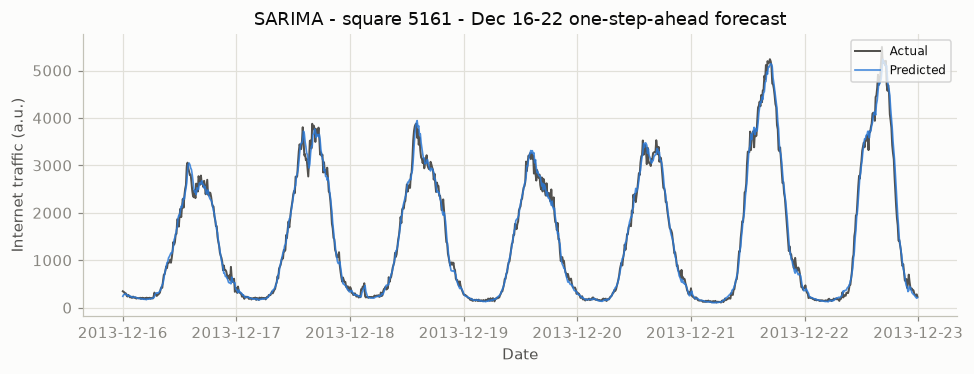

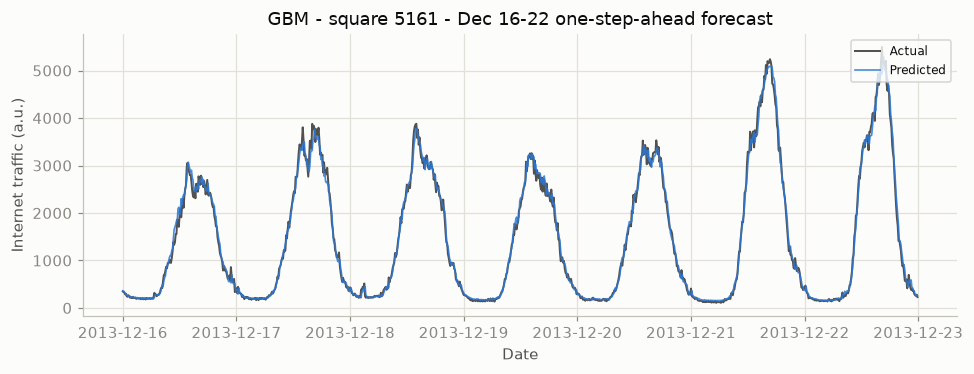

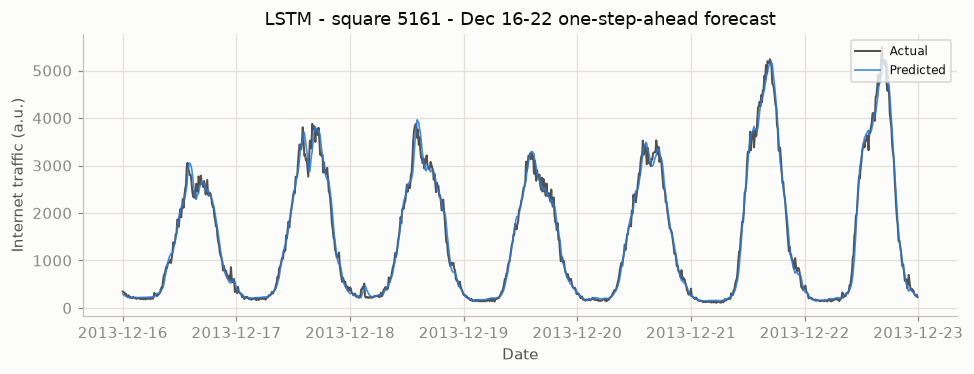

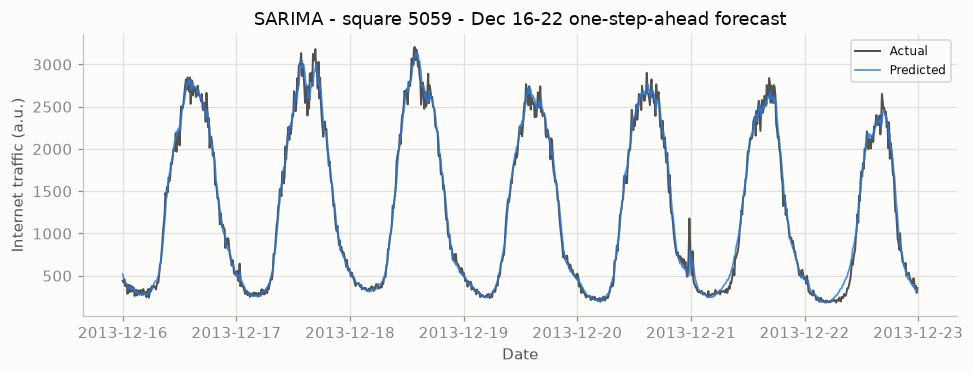

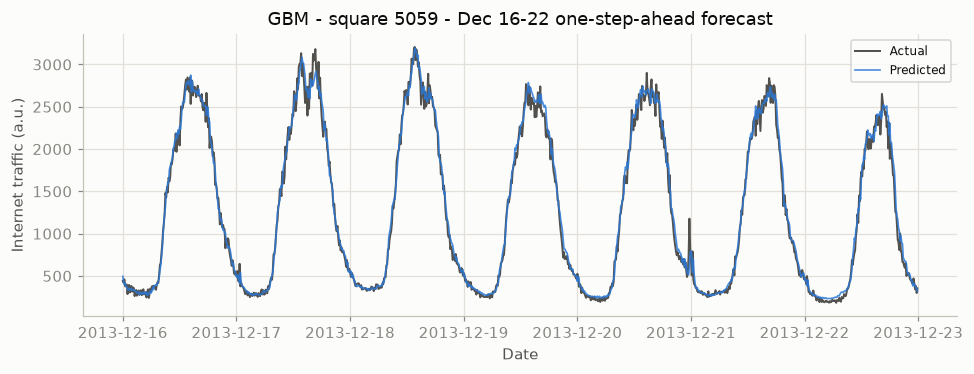

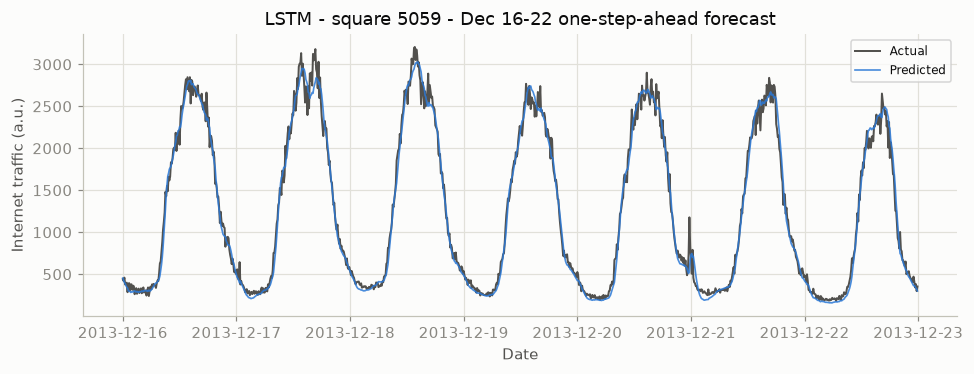

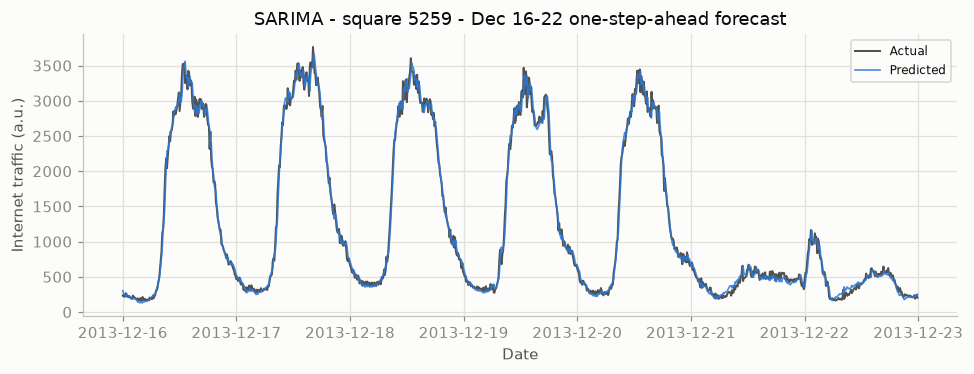

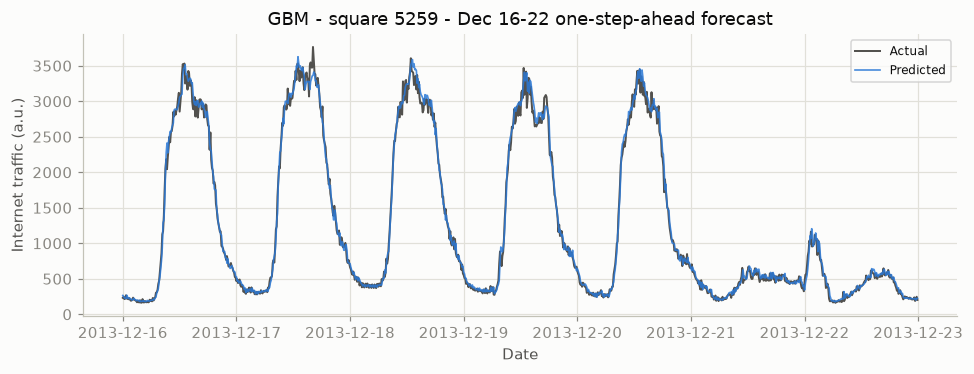

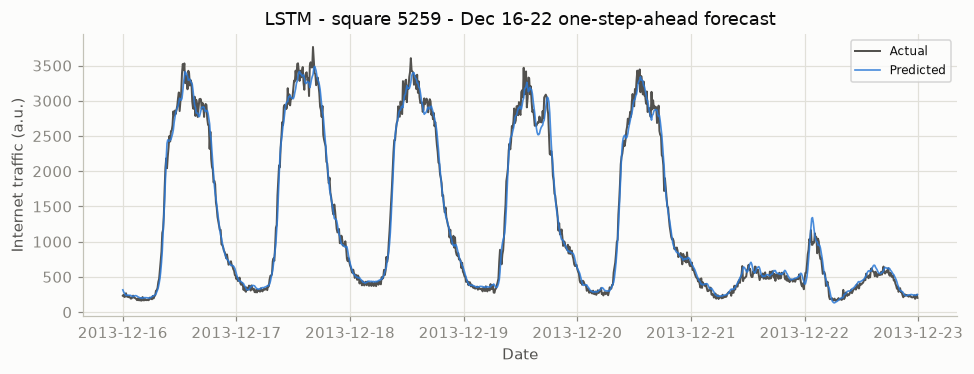

In [3]:
# Nine actual-vs-predicted plots (3 models x 3 squares).
for square_id in TOP3:
    actuals = pd.read_csv(RESULTS_DIR / f"actuals_{square_id}.csv", index_col=0, parse_dates=True)["actual"]
    for model_name in MODEL_NAMES:
        preds = pd.read_csv(RESULTS_DIR / f"predictions_{model_name.lower()}_{square_id}.csv", index_col=0, parse_dates=True)["prediction"]

        fig, ax = plt.subplots(figsize=(9, 3.5))
        ax.plot(actuals.index, actuals.values, color=INK_SECONDARY, label="Actual", linewidth=1.3)
        ax.plot(preds.index, preds.values, color=CATEGORICAL[0], label="Predicted", linewidth=1.1, alpha=0.85)
        ax.set_title(f"{model_name} - square {square_id} - Dec 16-22 one-step-ahead forecast")
        ax.set_xlabel("Date"); ax.set_ylabel("Internet traffic (a.u.)")
        ax.legend(loc="upper right", fontsize=8)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f"forecast_{model_name.lower()}_{square_id}.png")
        plt.show()
        plt.close(fig)

In [4]:
# Checked, not assumed: which model is closest at each day's single highest
# point, for square 5161's test week? (Verifies whether GBM's aggregate MAE
# advantage comes from consistently nailing peaks specifically, or from
# something else.)
actuals_5161 = pd.read_csv(RESULTS_DIR / "actuals_5161.csv", index_col=0, parse_dates=True)["actual"]
preds_5161 = {m: pd.read_csv(RESULTS_DIR / f"predictions_{m.lower()}_5161.csv", index_col=0, parse_dates=True)["prediction"] for m in MODEL_NAMES}
peak_winners = []
for day, day_actuals in actuals_5161.groupby(actuals_5161.index.date):
    peak_ts = day_actuals.idxmax()
    errs = {m: abs(preds_5161[m].loc[peak_ts] - actuals_5161.loc[peak_ts]) for m in MODEL_NAMES}
    peak_winners.append({"day": day, "actual_peak": round(actuals_5161.loc[peak_ts], 1), "closest_model": min(errs, key=errs.get)})
pd.DataFrame(peak_winners)

,day,actual_peak,closest_model
0,2013-12-16,3057.3,GBM
1,2013-12-17,3877.0,SARIMA
2,2013-12-18,3877.4,LSTM
3,2013-12-19,3258.2,SARIMA
4,2013-12-20,3529.7,GBM
5,2013-12-21,5238.3,LSTM
6,2013-12-22,5496.4,SARIMA


**Interpretation.** All nine panels track the daily rise-and-fall shape
closely - expected, given how strong the daily periodicity found in
`01_eda.ipynb` is, and all three input representations capture it one way or
another (Fourier terms, calendar features, or a full-day window). Checking
which model is closest at each single day's highest point (table above)
shows **no model consistently wins at individual peaks** - the closest model
varies day to day across the test week. This matters for how to read GBM's
aggregate MAE/RMSE advantage from the tables above: it is **not** coming
from GBM specifically nailing sharp peaks better than SARIMA or LSTM: it
comes from more consistent accuracy across the *whole* week (troughs,
ordinary daytime hours, and peaks alike), not from winning at the moments
that look most dramatic in these plots. LSTM's visible tendency to lag
entering and leaving each day's rise is real (visible across all three
squares) and consistent with it having the highest MAE/RMSE overall, even
though it isn't the worst model at every single peak checked above.

In [5]:
# Training / prediction timing, with hardware noted.
timing_df = pd.read_csv(RESULTS_DIR / "timing.csv")
hw = hardware_info()
print(json.dumps(hw, indent=2))

# Computed ranges (not eyeballed) - wall-clock timing is noisier run-to-run
# than the deterministic accuracy metrics, so these are measured fresh here
# rather than quoted as fixed numbers in the surrounding prose.
timing_ranges = timing_df.groupby("model")[["train_seconds", "predict_seconds"]].agg(["min", "max"]).round(1)
print("Per-model train/predict second ranges across the 3 squares:")
print(timing_ranges)
timing_df

{
  "platform": "Windows-11-10.0.22621-SP0",
  "processor": "AMD64 Family 23 Model 17 Stepping 0, AuthenticAMD",
  "cpu_count_logical": 4,
  "cpu_count_physical": 4,
  "total_ram_gb": 10.9
}
Per-model train/predict second ranges across the 3 squares:
       train_seconds       predict_seconds       
                 min   max             min    max
model                                            
GBM              3.7   3.8             8.9    9.2
LSTM            37.4  38.7             2.2    2.9
SARIMA           5.8  17.2           114.8  118.0


,square,model,train_seconds,predict_seconds,mae,mape,rmse
0,5161,SARIMA,5.792,117.966,82.567241,8.536348,124.255727
1,5161,GBM,3.690,8.974,80.668467,8.639132,117.483657
2,5161,LSTM,38.669,2.177,91.459941,9.720637,136.583626
3,5059,SARIMA,16.875,116.042,71.359843,8.095990,98.150015
4,5059,GBM,3.763,9.168,69.728171,7.330903,99.161200
5,5059,LSTM,38.071,2.501,75.931211,8.476002,105.257291
6,5259,SARIMA,17.233,114.816,69.786836,8.556452,96.490553
7,5259,GBM,3.815,8.920,64.393131,7.230160,90.625046
8,5259,LSTM,37.362,2.884,76.006685,9.045989,107.121330


**Interpretation.** Measured on the single machine described by the hardware
block above (4-core/4-thread AMD64, 11GB RAM, CPU only - no GPU used for the
LSTM), **as a single run per (model, square) combination**, not averaged or
repeated (stated explicitly here and in `02_experiments.ipynb`'s evaluation-
protocol section, per assignment Section 4-IV). Reading the ranges computed
above: GBM trains fastest of the three; SARIMA's training also stays fast
(the Fourier-term reformulation in `forecasting/sarima_forecaster.py` avoids
the >19-CPU-minute literal-seasonal-ARIMA blowup measured during
development), but SARIMA's one-step Kalman-filter walk-forward prediction
over the 1,008-step test week is by far the slowest *prediction* step of any
model here - roughly an order of magnitude past its own training time, and
well past GBM's or LSTM's prediction time too. LSTM is slowest to *train* of
the three but fastest to *predict* (a single forward pass per step, faster
even than GBM's per-step feature construction).

Put together with the accuracy tables above: **LSTM's extra training cost
buys no accuracy advantage here - it is both the most expensive model to
train and the least accurate on every square**, which is the single clearest
quantitative reason to prefer GBM for this dataset and this compute budget.
SARIMA's slow *prediction* step is a separate, secondary weakness - real for
a use case needing fast repeated re-forecasting, but not what makes it lose
to GBM on accuracy (it doesn't; SARIMA is consistently second-best, ahead of
LSTM). With a larger time budget, the natural next step is repeating each
measurement 3-5 times to report variance alongside these point estimates,
which single-run timing cannot distinguish from measurement noise.

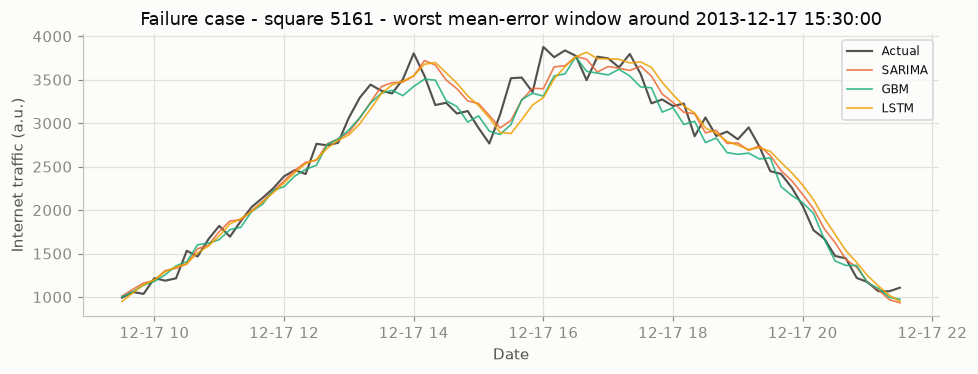

Worst mean-absolute-error timestamp across all 3 models: 2013-12-17 15:30:00
Per-model absolute error at 2013-12-17 15:30:00:
SARIMA    485.579187
GBM       533.191088
LSTM      637.860378
Name: 2013-12-17 15:30:00, dtype: float64


,SARIMA,GBM,LSTM
count,73.000000,73.000000,73.000000
mean,135.486582,134.150438,162.489763
std,112.142681,112.618198,137.768014
min,1.407103,2.308211,4.470977
25%,42.872376,43.026289,50.383381
50%,115.710420,127.344324,131.690505
75%,180.564610,188.561674,238.581949
max,485.579187,565.941982,637.860378


In [6]:
# Failure case: the test-week timestamp with the largest mean absolute error
# across all three models, for the top-traffic square.
top_square = TOP3[0]
actuals = pd.read_csv(RESULTS_DIR / f"actuals_{top_square}.csv", index_col=0, parse_dates=True)["actual"]
preds_by_model = {
    m: pd.read_csv(RESULTS_DIR / f"predictions_{m.lower()}_{top_square}.csv", index_col=0, parse_dates=True)["prediction"]
    for m in MODEL_NAMES
}

errs = pd.DataFrame({m: (actuals - preds_by_model[m]).abs() for m in MODEL_NAMES}).dropna()
worst_ts = errs.mean(axis=1).idxmax()
window = slice(worst_ts - pd.Timedelta(hours=6), worst_ts + pd.Timedelta(hours=6))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(actuals.loc[window].index, actuals.loc[window].values, color=INK_SECONDARY, label="Actual", linewidth=1.4)
for i, m in enumerate(MODEL_NAMES):
    p = preds_by_model[m].loc[window]
    ax.plot(p.index, p.values, color=CATEGORICAL[i + 1], label=m, linewidth=1.1, alpha=0.85)
ax.set_title(f"Failure case - square {top_square} - worst mean-error window around {worst_ts}")
ax.set_xlabel("Date"); ax.set_ylabel("Internet traffic (a.u.)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "failure_case.png")
plt.show()

print(f"Worst mean-absolute-error timestamp across all 3 models: {worst_ts}")
print(f"Per-model absolute error at {worst_ts}:")
print(errs.loc[worst_ts].sort_values())
errs.loc[window].describe()

**Interpretation - what the plot actually shows, not a hypothetical:** the
worst shared moment in the test week is **2013-12-17 15:30**, square 5161.
Ten minutes earlier the true series had dipped to 2,766 (from ~3,100-3,200
over the preceding hour); by 15:30 it had rebounded sharply to 3,518 - a
+751 move in a single 10-minute step, well outside this square's typical
step-to-step change. All three models, conditioned on the dip, predicted a
continued low value: SARIMA 3,032 (error 486), GBM 2,984 (error 533), **LSTM
2,880 (error 638, the largest of the three at this specific step)** - the
opposite of LSTM's overall ranking, where it has the *most* error on
average but here is not simply "worse everywhere," it is worse specifically
at sudden reversals its raw 144-point window doesn't flag as unusual. None
of the three input representations - a handful of Fourier harmonics, 13
lag/calendar features, or a raw day-length window - encode "this dip is
about to reverse sharply" as a knowable-in-advance signal; all three are
built to extrapolate the recent local trend, which is exactly wrong at this
specific step. This is a concrete, evidenced limitation of all three
approaches as configured here, not a weakness of one model relative to the
others - consistent with Santos et al. [1]'s finding (cited in
`02_experiments.ipynb`) that recurrent models (and, this project's evidence
suggests, the other two paradigms as well) degrade specifically during
atypical, underrepresented local patterns, even while aggregate week-level
metrics look reasonable.